In [6]:

# Import Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# Load Dataset
dataset = load_dataset('Sumedchakma/jobs_record')
df = dataset['train'].to_pandas()


#---------------
# Data Cleaning
#---------------

# Convert job_posted_date to datetime
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Convert job_skills from string to list
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

Repo card metadata block was not found. Setting CardData to empty.


In [7]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & 
              (df['job_country'] == 'United States')].copy()



# drop Nan values from the salary year avg column for accurate visualization
df_DA_US = df_DA_US.dropna(subset =['salary_year_avg'])

In [8]:
df_DA_US = df_DA_US.explode('job_skills')

df_DA_US[['salary_year_avg', 'job_skills']]


,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel
...,...,...
784882,87500.0,sql
784882,87500.0,vba
784882,87500.0,tableau
784882,87500.0,excel


In [9]:
# Group by skill and calculate count & median salary
df_DA_US_group = (
    df_DA_US
    .groupby('job_skills')['salary_year_avg']
    .agg(['count', 'median'])
)

# Top 10 highest median paying skills
df_DA_top_pay = (
    df_DA_US_group
    .sort_values(by='median', ascending=False)
    .head(10)
)

# Top 10 most in-demand skills (by count), then sort them by median salary
df_DA_skills = (
    df_DA_US_group
    .sort_values(by='count', ascending=False)
    .head(10)
    .sort_values(by='median', ascending=False)
)

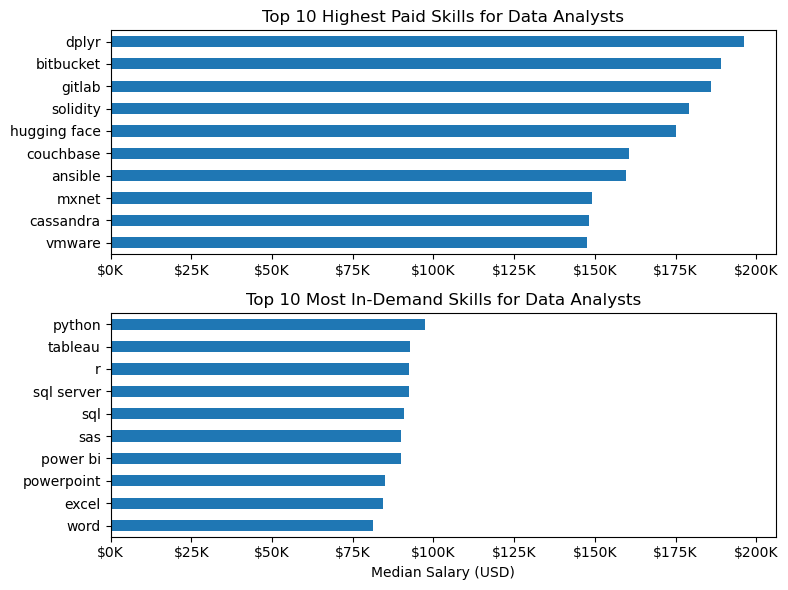

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Top 10 Highest Paid Skills
df_DA_top_pay[::-1].plot(
    kind='barh',
    y='median',
    ax=ax[0],
    legend=False
)

ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
)


# Top 10 Most In-Demand Skills
df_DA_skills[::-1].plot(
    kind='barh',
    y='median',
    ax=ax[1],
    legend=False
)

ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
)

# Make both charts share same x-axis scale
ax[1].set_xlim(ax[0].get_xlim())

plt.tight_layout()
plt.show()